**Table of contents**<a id='toc0_'></a>    
- [Fluopy trials notebook](#toc1_)    
  - [Importing all modules](#toc1_1_)    
  - [Routine template](#toc1_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Fluopy trials notebook](#toc0_)
This notebook is dedicated to test functionality of fluopy

## <a id='toc1_1_'></a>[Importing all modules](#toc0_)

In [13]:
import fluopy.emissions as em
import fluopy.fcs as fcs_p
import fluopy.figure as fi
import fluopy.fluorophores as fl
import fluopy.prediction as pr
import fluopy.simulation as si
import fluopy.transitions as tr

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## <a id='toc1_2_'></a>[Routine template](#toc0_)

In [28]:
import numpy as np

In [31]:
rng = np.random.default_rng(3)
fluorophores = fl.construct_fluorophores(
    name="S0S1System", count=4, distance=3, shape="square"
)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = [
    tr.Transition(
        tr.TransitionType.INTERNAL_CONVERSION_S,
        rate=4.2e8,
        fluorophore_ids=[0, 1, 2, 3],
    ),
    tr.Transition(
        tr.TransitionType.FLUORESCENT_EMISSION, rate=1.6e8, fluorophore_ids=[0, 1, 2, 3]
    ),
    tr.Transition(
        tr.TransitionType.EXCITATION,
        rate=7.3e6,
        fluorophore_ids=[0, 1, 2, 3],
    ),
]
transition_set = tr.TransitionSet({"S0S1System": transitions}, fluorophore_system)
transition_set.finalize()
emissions = em.Emissions()
emissions.tcspc(transition_set, number_pulses=1e6, store_time_points=True)

hist_multi_f, bins_multi_f = fcs_p.coincidence(
    emissions.event_time_points, 1e-7, 1e-10, seed=rng
)

Fluorophore S0S1System not known. Parameters have to be defined manually.
Fluorophore S0S1System not known. Parameters have to be defined manually.
Fluorophore S0S1System not known. Parameters have to be defined manually.
Fluorophore S0S1System not known. Parameters have to be defined manually.
The irradiance used initially for excitation rates in
 transition_set is now assumed to be the mean irradiance of
 pulse and no pulse duration.
the last frame (of index 0.1) has 1.00e+00 times the pulses of other frames.


In [33]:
hist_multi_f, bins_multi_f = fcs_p.coincidence(
    emissions.event_time_points, 1e-6, 1e-10, seed=rng
)

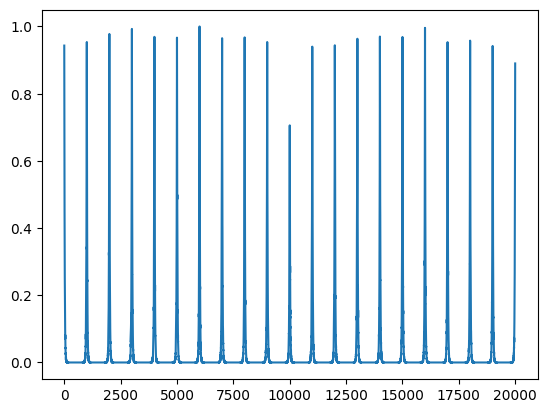

In [35]:
plt.plot(
    hist_multi_f / hist_multi_f.max(),
)

In [23]:
fluorophores = fl.construct_fluorophores(
    name="cy5_dna", distance=3, count=4, shape="square"
)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

transitions = fluorophore_system.load_transitions(
    summarize=True,
    irradiance=5,
    wavelength=640,
    bleaching=False,
    energy_transfer=False,
    dstorm=False,
    dstorm_parameters={"reducing_agent": "mea", "concentration": 100, "ph": 7.5},
    energy_transfer_parameters={"overwrite": {"off": [1, 0.00001]}},
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.adjust_rates({8: 5e1})
transition_set.finalize()

transition_set.transition_df

transition_type abbreviation  \
Fluorophore identity                                                        
cy5_dna     0                      TransitionType.EXCITATION          EXC   
            1            TransitionType.FLUORESCENT_EMISSION          FLU   
            2         TransitionType.INTERSYSTEM_CROSSING_ST       ISC_ST   
            3                   TransitionType.ISOMERIZATION          ISO   
            4               TransitionType.S1_S0_TRANSITIONS      S1S0SUM   
            5               TransitionType.T1_S0_TRANSITIONS      T1S0SUM   
            6              TransitionType.CIS_S0_TRANSITIONS     cisS0SUM   

                        initial_state      final_state          rate  photon  \
Fluorophore identity                                                           
cy5_dna     0          SingleState.S0   SingleState.S1  1.453925e+07   False   
            1          SingleState.S1   SingleState.S0  1.588235e+08    True   
            2          SingleState.S1   SingleState.T1  8.300000e+05   False   
            3          SingleState.S1  SingleState.cis  4.000000e+06   False   
            4          SingleState.S1   SingleState.S0  4.245818e+08   False   
            5          SingleState.T1   SingleState.S0  5.000000e+03   False   
            6         SingleState.cis   SingleState.S0  1.016550e+05   False   

                     fluorophore_ids  absorbing  
Fluorophore identity                             
cy5_dna     0           [0, 1, 2, 3]      False  
            1           [0, 1, 2, 3]      False  
            2           [0, 1, 2, 3]      False  
            3           [0, 1, 2, 3]      False  
            4           [0, 1, 2, 3]      False  
            5           [0, 1, 2, 3]      False  
            6           [0, 1, 2, 3]      False

In [24]:
sim = si.Simulation(transition_set)
sim.run(size=2e6, seed=2)
emissions = em.Emissions()
emissions.extract(sim)

hist_multi_f, bins_multi_f = fcs_p.coincidence(
    emissions.event_time_points, 1e-7, 1e-10, seed=5
)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 4.25e-13.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.


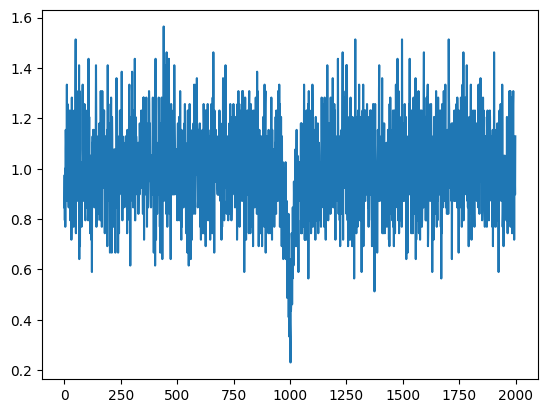

In [26]:
import matplotlib.pyplot as plt

plt.plot(hist_multi_f / hist_multi_f.mean())

In [ ]:
sim = si.Simulation(transition_set)
sim.run(size=1e7, kap_sq_var=False, seed=42, use_memmap=None)

In [3]:
pred = pr.Prediction(transition_set)

absorbing states have a lifetime of inf and a frequency / occupation of 0. Absorbing transitions have a frequency of 0.


In [6]:
sim.approximate(prediction=pred, size=4e6, seed=1)

approximation ignors absorbing states, they will not occur.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.69e-12.
 This was estimated using the highest possible rate which occurs for example in state combination [1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.


In [19]:
hist, bins = fcs_p.coincidence_with_normalization(
    emis.event_time_points[:1000000], 1e-6, 5e-10, seed=2, method="numba"
)

array([[<Axes: xlabel='x', ylabel='y'>]], dtype=object)

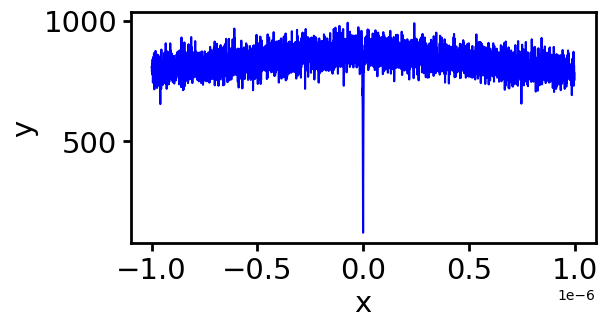

: 

In [ ]:
fi.universal_figure(type_="line", data=[bins[:-2], hist])